# Trackpoint Analysis

**Purpose:** load tracker + GPS data, clean it, and visualize truck paths — optionally overlaid on mine zone polygons. This is the general-purpose exploration notebook; route extraction and clustering live in `route_clustering_analysis.ipynb`.

In [1]:
import sys
sys.path.append("../..")

from gps_lib import io_utils, classify, preprocess, plotting

In [ ]:
import importlib
import gps_lib.io_utils, gps_lib.classify, gps_lib.preprocess, gps_lib.plotting

for _m in (gps_lib.io_utils, gps_lib.classify, gps_lib.preprocess, gps_lib.plotting):
    importlib.reload(_m)

from gps_lib import io_utils, classify, preprocess, plotting

In [2]:
tracker_list_df = io_utils.load_tracker_list()
tracker_list_df = classify.classify_technic_material_type(tracker_list_df)
tracker_list_df.groupby(["technic_type", "technic_m_type"])["label"].count()

technic_type  technic_m_type
dump          bn                48
              other             41
loader        other             14
other         other             20
Name: label, dtype: int64

In [ ]:
track_points_df = io_utils.load_gps_data()
track_points_df.shape

In [4]:
merged_df = preprocess.attach_technic_info(track_points_df, tracker_list_df)

START_TIME = "2025-11-01 00:00:00"
END_TIME = "2025-11-04 10:00:00"
filtered_df = preprocess.filter_by_time(merged_df, START_TIME, END_TIME)
filtered_df[["tracker_id", "label", "get_time", "lat", "lng", "technic_type"]].head()

,tracker_id,label,get_time,lat,lng,technic_type
0,18773,HDU506 82-76ТТА,2025-11-01 00:00:04,43.665645,105.534713,dump
1,18773,HDU506 82-76ТТА,2025-11-01 00:00:24,43.665645,105.534713,dump
2,18773,HDU506 82-76ТТА,2025-11-01 00:00:44,43.665645,105.534713,dump
3,18773,HDU506 82-76ТТА,2025-11-01 00:01:04,43.665645,105.534713,dump
4,18773,HDU506 82-76ТТА,2025-11-01 00:01:24,43.665645,105.534713,dump


In [5]:
df_cleaned = preprocess.clean_gps_points(filtered_df, round_n=4)
print(f"Removed {filtered_df.shape[0] - df_cleaned.shape[0]} near-duplicate points")
df_cleaned.shape

Removed 592216 near-duplicate points


(703180, 30)

,idx,tracker_id,label,count
0,0,45505,BN143 /73-95 УКО/,17987
1,1,56574,HDU559/72-01УР/,17817
2,2,56575,HDU561/72-03УР/,17622
3,3,56572,HDU560,17604
4,4,52151,HDU575 18-56 MMA,17538
5,5,56039,BN177,17160
6,6,45504,BN142 /73-94 УКА/,17081
7,7,48890,BN153 69-93 УНЭ,16840
8,8,45598,BN145 / 71-23 УКО,16633
9,9,53116,HDU585 23-77 ММА,16406


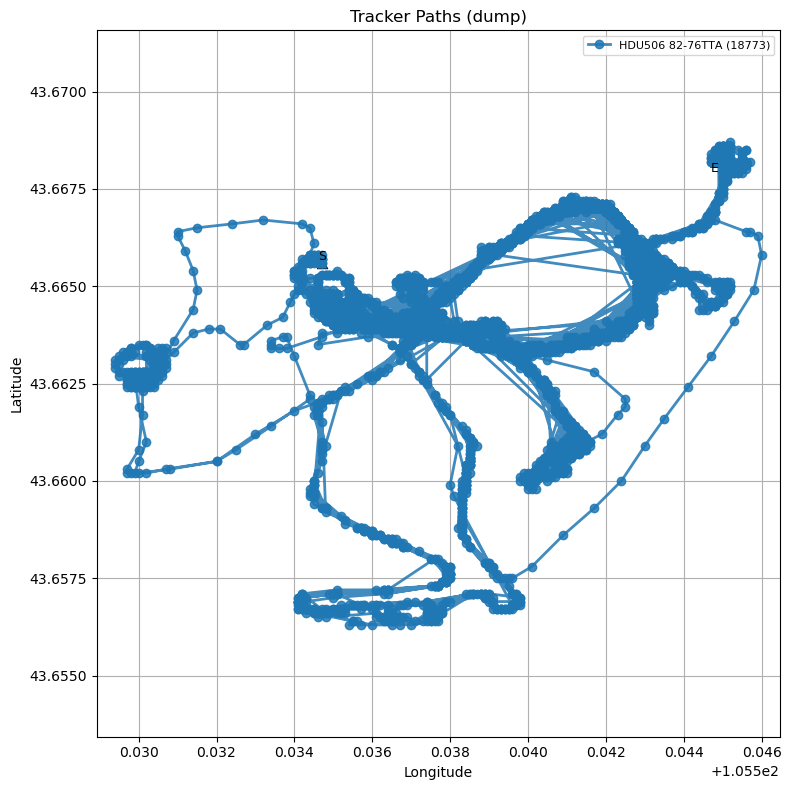

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Tracker Paths (dump)'}, xlabel='Longitude', ylabel='Latitude'>)

In [6]:
display(plotting.list_technics(df_cleaned, technic_type="dump", max_rows=10))
plotting.plot_tracker_paths(df_cleaned, technic_idx=0, technic_type="dump")

Filtered to technic_m_type='bn': 28 unique trackers


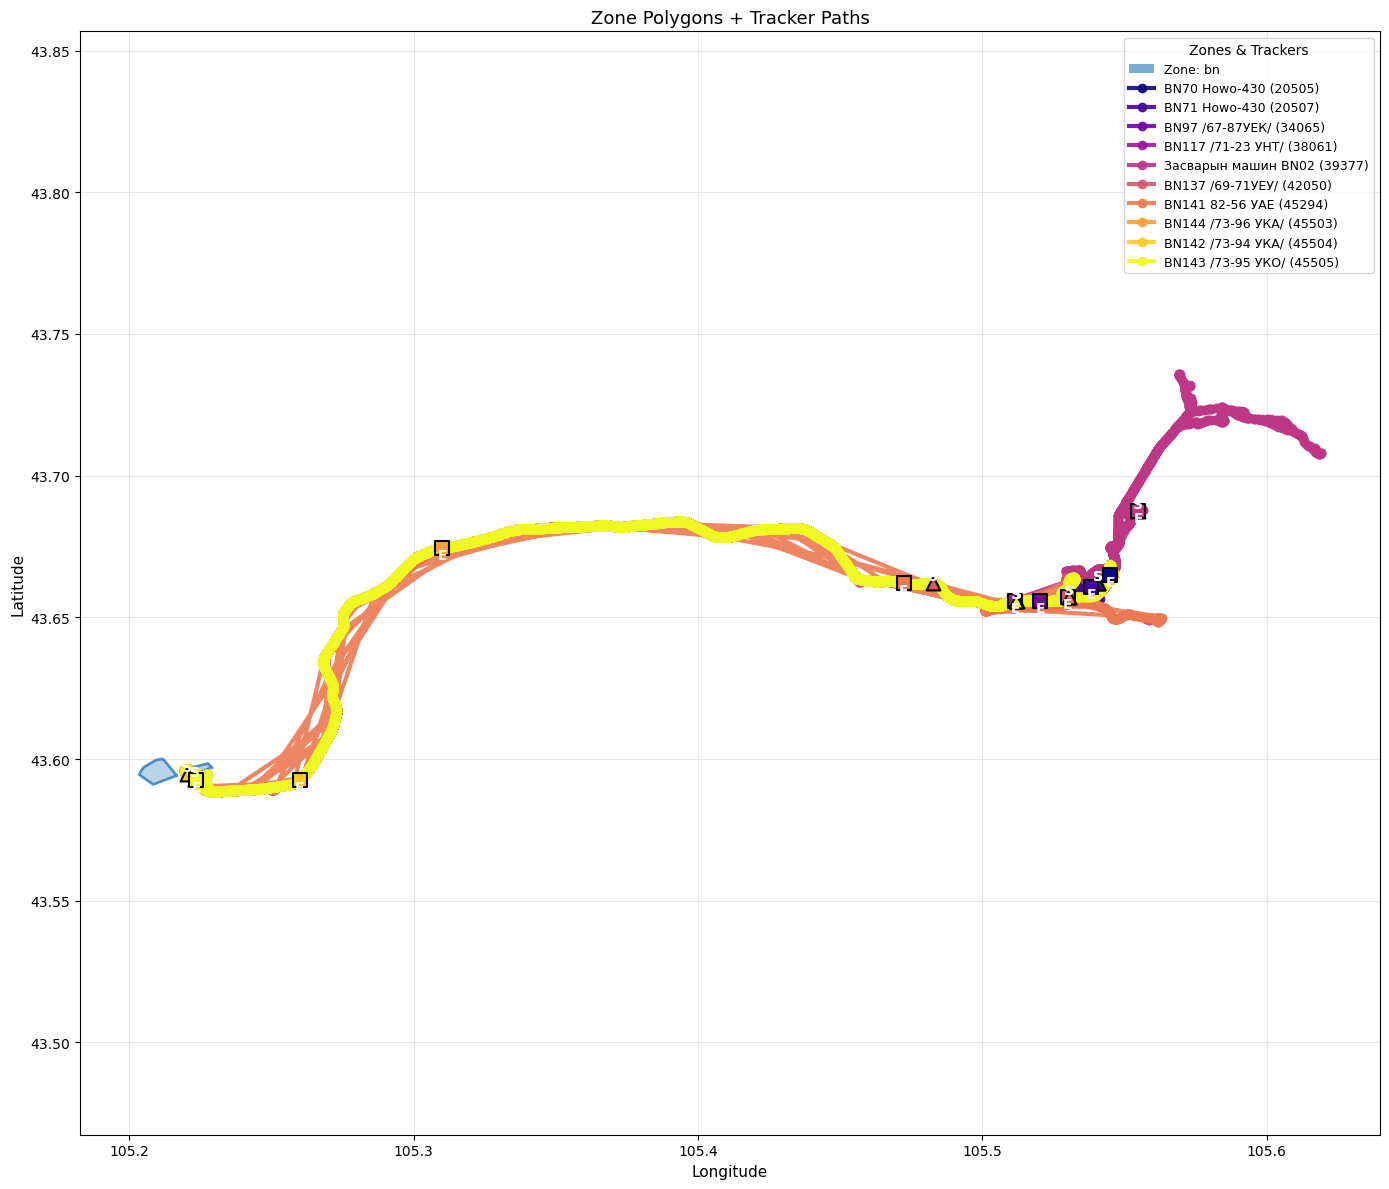

In [7]:
# Overlay with mine zones (requires data/zone_list.csv + data/zone_detail_all_df.csv,
# produced by notebooks/api/fetch_zones.ipynb)
try:
    zone_list_df = io_utils.load_zone_list()
    zone_detail_all_df = io_utils.load_zone_detail()
    zone_filtered_df = classify.classify_zones(zone_list_df, drop_other=True)

    plotting.plot_zones_with_tracker_paths(
        zone_df=zone_detail_all_df,
        zone_meta_df=zone_filtered_df,
        tracker_df=df_cleaned,
        material_types=["bn"],
        load_types=["load", "unload"],
        n=10,
        technic_type="dump",
        technic_m_type="bn",
        figsize=(14, 12),
    )
except FileNotFoundError as e:
    print(f"Zone data files not found: {e}")
    print("Run notebooks/api/fetch_zones.ipynb first.")

In [8]:
# Date coverage summary
unique_dates = sorted(df_cleaned["date"].unique())
print(f"Total unique days: {len(unique_dates)}")
print(f"Range: {df_cleaned['date'].min()} -> {df_cleaned['date'].max()}")
for date in unique_dates:
    print(f"  {date}: {(df_cleaned['date'] == date).sum():,} points")

Total unique days: 4
Range: 2025-11-01 -> 2025-11-04
  2025-11-01: 210,427 points
  2025-11-02: 217,570 points
  2025-11-03: 199,291 points
  2025-11-04: 75,892 points
